In [1]:
import sys
sys.path.append('../src/evaccast_v1/')

In [2]:
import json

import geopandas as gpd
import pandas as pd
import numpy as np
import shapely as sh
from shapely.geometry import shape

# from evaccast.api.v1.routing import _fetch_pruned_graph, route_between_regions
from evaccast.api.v1.routing import route_between_areas

In [3]:
import gzip, pickle

# EvacCast scenario

In [4]:
with open('../data/scenarios/bruxelles-scenario-soignes.pkl', 'rb') as f:
    scenario = pickle.load(f)

In [5]:
source_areas, target_areas, avoid_areas = scenario['source_areas'], scenario['target_areas'], scenario['avoid_areas']
avoid_areas = [a['shape'] for a in scenario['avoid_areas']]  # unwrap {"name","shape"} dicts -> bare geometries


### check scenario corresponds to what we saw in UI

In [6]:
scenario['source_areas']

[{'name': 'area_00',
  'shape': <POLYGON ((4.364 50.783, 4.364 50.784, 4.364 50.784, 4.364 50.784, 4.365 50....>,
  'population': 13441,
  'population-distribution': {'compliant': 70,
   'self-directed': 20,
   'disoriented': 10},
  'vehicle_occupancy': None},
 {'name': 'area_01',
  'shape': <POLYGON ((4.395 50.755, 4.394 50.754, 4.394 50.754, 4.393 50.754, 4.391 50....>,
  'population': 12829,
  'population-distribution': {'compliant': 70,
   'self-directed': 20,
   'disoriented': 10},
  'vehicle_occupancy': None},
 {'name': 'area_02',
  'shape': <POLYGON ((4.411 50.772, 4.413 50.772, 4.413 50.772, 4.415 50.773, 4.416 50....>,
  'population': 1000,
  'population-distribution': {'compliant': 70,
   'self-directed': 20,
   'disoriented': 10},
  'vehicle_occupancy': None},
 {'name': 'area_03',
  'shape': <POLYGON ((4.491 50.786, 4.491 50.786, 4.49 50.786, 4.49 50.786, 4.49 50.785...>,
  'population': 5000,
  'population-distribution': {'compliant': 70,
   'self-directed': 20,
   'disorie

In [7]:
scenario['target_areas']

[{'name': 'heysel',
  'shape': <POLYGON ((4.329 50.897, 4.333 50.897, 4.339 50.897, 4.341 50.895, 4.336 50....>,
  'capacity': 100000,
  'vehicle_occupancy': None}]

In [7]:
scenario['vehicle_fleets']

[{'name': 'houtweg 99',
  'lat': 50.87864299988982,
  'lon': 4.410273724488832,
  'count': 50,
  'capacity_per_unit': 40,
  'speed': 25,
  'load_unload_secs_per_person': 10},
 {'name': 'biplan 75',
  'lat': 50.88339923624641,
  'lon': 4.410324380235859,
  'count': 50,
  'capacity_per_unit': 40,
  'speed': 25,
  'load_unload_secs_per_person': 10},
 {'name': 'industriel 14',
  'lat': 50.82859625785035,
  'lon': 4.317950608423478,
  'count': 50,
  'capacity_per_unit': 40,
  'speed': 25,
  'load_unload_secs_per_person': 10},
 {'name': 'vandermeeren 1',
  'lat': 50.84707131348827,
  'lon': 4.321116547230933,
  'count': 50,
  'capacity_per_unit': 40,
  'speed': 25,
  'load_unload_secs_per_person': 10},
 {'name': 'tyras 15',
  'lat': 50.90848731036625,
  'lon': 4.395375235430757,
  'count': 50,
  'capacity_per_unit': 40,
  'speed': 25,
  'load_unload_secs_per_person': 10}]

In [8]:
len(scenario['vehicle_fleets'])

5

In [13]:
computation = route_between_areas(
    source_areas, target_areas, avoid_areas=avoid_areas, 
    time_horizon_hours=96, speed_override_kph=25
)

In [9]:
evacuation_paths = computation.vehicle_paths
len(evacuation_paths)

18

In [12]:
p = evacuation_paths[2]
type(p)

shapely.geometry.multilinestring.MultiLineString

In [11]:
categories = (
    ['source'] * len(source_areas)
    + ['target'] * len(target_areas)
    + ['avoid'] * len(avoid_areas)
    + ['path'] * len(computation.vehicle_paths)
)

all_geoms = [i['shape'] for i in source_areas] + \
            [i['shape'] for i in target_areas] + \
            avoid_areas + \
            computation.vehicle_paths          # one MultiLineString per bus

gdf = gpd.GeoDataFrame(
    {'geometry': all_geoms, 'category': categories},
    crs='EPSG:4326'
)


# gpd.GeoDataFrame(all_geoms, columns=['geometry'], crs='EPSG:4326').explore()
gdf.explore(
    column='category',
    categorical=True,
    categories=['source', 'target', 'avoid', 'path'],   # controls color order below
    cmap=['#FFD700', '#2CA02C', '#D62728', '#1F77B4'],  # yellow, green, red, blue
    legend=True,
    style_kwds={'style_function': lambda f: {
        'weight': 4 if f['properties']['category'] == 'path' else 2,
        'fillOpacity': 0 if f['properties']['category'] == 'path' else 0.35,
    }},
)

In [17]:
len(computation.vehicle_paths)

22

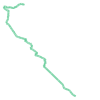

In [27]:
computation.vehicle_paths[0]

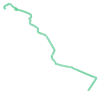

In [28]:
computation.vehicle_paths[1]

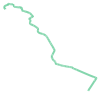

In [29]:
computation.vehicle_paths[2]